# Tahap 1: Preprocessing & Feature Engineering
Notebook ini berfokus pada tiga tahapan utama untuk mempersiapkan data mentah Posyandu sebelum dilatih oleh Machine Learning:

1. **Pembersihan Data (Preprocessing):** Meratakan struktur data dari format Excel (*MultiIndex*) dan memfilter anomali nilai yang kosong.
2. **Rekayasa Fitur (Feature Engineering):** Mengekstrak fitur Kecepatan_Tumbuh (Tinggi dan Berat) secara dinamis, **serta menyuntikkan kalkulasi mutlak Z-Score WHO**. Ini memberikan jangkar kepastian medis bagi model sekaligus memungkinkannya mendeteksi gejala awal gagal tumbuh (*Faltering Growth*).
3. **Simulasi Parametrik & Augmentasi Data:** Menyuntikkan 500 profil pasien virtual (250 Normal, 250 Stunting) dengan korelasi klinis yang terkunci presisi sesuai batas Z-Score WHO. Setelah itu, metode SMOTE digunakan untuk menyeimbangkan sedikit selisih data, menghasilkan sekitar 602 baris dataset final yang sangat robust secara medis.

In [94]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### 1. Load Data

In [95]:
raw_data_path = '../data/raw/dataset_posyandu.xlsx'
df = pd.read_excel(raw_data_path, header=[0, 1])

# Gabungkan multi-level header menjadi satu baris
new_cols = []
for c in df.columns:
    if 'Unnamed' in str(c[1]):
        new_cols.append(c[0])
    elif 'Unnamed' in str(c[0]):
        new_cols.append(c[1])
    else:
        new_cols.append(f"{c[0]}_{c[1]}")
df.columns = new_cols
df.head(3)

,No,Nama,Umur (Bulan),Jenis Kelamin,OrangTua,Alamat (Dusun),January_BB(kg),January_TB(cm),February_BB(kg),February_TB(cm),March_BB(kg),March_TB(cm),April_BB(kg),April_TB(cm),May_BB(kg),May_TB(cm),NORMAL(0) STUNTING (1)
0,1,CHAIRUNISA SALSABILA PUTRI,27,P,NaN,PAHING,10.8,81.7,11.1,82.4,11,83.0,10.80,84.0,11.2,86.0,0
1,2,DEANDRA ALFATHUNISA SYAFAZEA,36,P,NaN,PAHING,10.3,83.6,10.4,83.6,10.4,84.6,10.80,86.8,11.0,87.0,0
2,3,ARLEYAVA EVELYN PERMANA P,18,P,NaN,PAHING,8.0,72.0,8.4,73.0,8.5,73.6,8.67,74.3,9.0,75.0,0


### 2. Exploratory Data Analysis (EDA)

In [96]:
# Cek Missing Values
print("=== Pengecekan Missing Values ===")
print(df.isnull().sum())
print("\n")


=== Pengecekan Missing Values ===
No                         0
Nama                       0
Umur (Bulan)               0
Jenis Kelamin              0
OrangTua                  71
Alamat (Dusun)             0
January_BB(kg)             0
January_TB(cm)             0
February_BB(kg)            0
February_TB(cm)            0
March_BB(kg)               0
March_TB(cm)               0
April_BB(kg)               0
April_TB(cm)               0
May_BB(kg)                 0
May_TB(cm)                 0
NORMAL(0) STUNTING (1)     0
dtype: int64




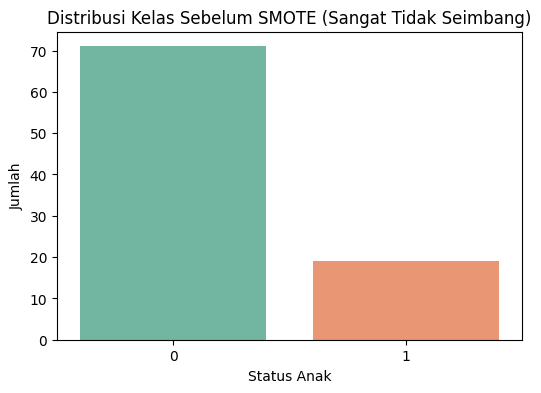

In [97]:
# Visualisasi Ketidakseimbangan Kelas (Class Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='NORMAL(0) STUNTING (1)', palette='Set2')
plt.title('Distribusi Kelas Sebelum SMOTE (Sangat Tidak Seimbang)')
plt.xlabel('Status Anak')
plt.ylabel('Jumlah')
plt.show()

### 3. Pembersihan Data

In [98]:
# Buang kolom identitas pasien
cols_to_drop = ['No', 'Nama', 'OrangTua', 'Alamat (Dusun)']
df_bersih = df.drop(columns=cols_to_drop, errors='ignore')

# Hapus baris kosong
df_bersih = df_bersih.dropna(how='all')
df_bersih.head(3)

,Umur (Bulan),Jenis Kelamin,January_BB(kg),January_TB(cm),February_BB(kg),February_TB(cm),March_BB(kg),March_TB(cm),April_BB(kg),April_TB(cm),May_BB(kg),May_TB(cm),NORMAL(0) STUNTING (1)
0,27,P,10.8,81.7,11.1,82.4,11,83.0,10.80,84.0,11.2,86.0,0
1,36,P,10.3,83.6,10.4,83.6,10.4,84.6,10.80,86.8,11.0,87.0,0
2,18,P,8.0,72.0,8.4,73.0,8.5,73.6,8.67,74.3,9.0,75.0,0


### 4. Feature Engineering Dinamis (Kecepatan Tumbuh)


In [99]:
bb_cols = [c for c in df_bersih.columns if 'BB' in c]
tb_cols = [c for c in df_bersih.columns if 'TB' in c]

# Ambil nilai awal dan akhir dari riwayat pengukuran
df_bersih['BB_Awal'] = df_bersih[bb_cols[0]]
df_bersih['TB_Awal'] = df_bersih[tb_cols[0]]
df_bersih['BB_Akhir'] = df_bersih[bb_cols[-1]]
df_bersih['TB_Akhir'] = df_bersih[tb_cols[-1]]

# Lama pantau dihitung dari jumlah kolom histori yang tersedia
df_bersih['Lama_Pantau_Bulan'] = len(bb_cols)

# Hitung kecepatan tumbuh per bulan (menghindari pembagian nol)
interval = df_bersih['Lama_Pantau_Bulan'] - 1
interval = interval.replace(0, 1) # Fallback jika hanya 1 bulan

df_bersih['Kecepatan_Tumbuh_BB'] = (df_bersih['BB_Akhir'] - df_bersih['BB_Awal']) / interval
df_bersih['Kecepatan_Tumbuh_TB'] = (df_bersih['TB_Akhir'] - df_bersih['TB_Awal']) / interval

df_bersih['Rasio_BB_TB_Akhir'] = df_bersih['BB_Akhir'] / (df_bersih['TB_Akhir'] + 0.001)

# Encoding Jenis Kelamin menjadi Numerik (L=1, P=0) agar bisa dibaca model ML
df_bersih['Jenis Kelamin'] = df_bersih['Jenis Kelamin'].map({'L': 1, 'P': 0})

# Seleksi hanya kolom fitur yang akan dipakai model
final_columns = ['Umur (Bulan)', 'Jenis Kelamin', 'BB_Awal', 'TB_Awal', 'BB_Akhir', 'TB_Akhir', 
                 'Lama_Pantau_Bulan', 'Kecepatan_Tumbuh_BB', 'Kecepatan_Tumbuh_TB', 'Rasio_BB_TB_Akhir', 'Status']

# Asumsi kolom target mengandung kata NORMAL atau STUNTING
target_col = [c for c in df_bersih.columns if 'NORMAL' in c.upper() or 'STUNTING' in c.upper()][0]
df_bersih = df_bersih.rename(columns={target_col: 'Status'})

df_fitur = df_bersih[final_columns]
df_fitur.head(3)

,Umur (Bulan),Jenis Kelamin,BB_Awal,TB_Awal,BB_Akhir,TB_Akhir,Lama_Pantau_Bulan,Kecepatan_Tumbuh_BB,Kecepatan_Tumbuh_TB,Rasio_BB_TB_Akhir,Status
0,27,0,10.8,81.7,11.2,86.0,5,0.100,1.075,0.130231,0
1,36,0,10.3,83.6,11.0,87.0,5,0.175,0.850,0.126435,0
2,18,0,8.0,72.0,9.0,75.0,5,0.250,0.750,0.119998,0


### 5. Injeksi Data Klinis Buatan

In [100]:
# Hapus baris kosong jika ada
df_fitur = df_fitur.dropna()

# Tabel Referensi WHO LMS (Lambda, Mu, Sigma) untuk Tinggi Badan menurut Umur (TB/U)n
# Format: [L, M, S] per indeks bulan

# Tabel Referensi WHO LMS untuk Anak Perempuan Usia 0-60 Bulan
WHO_LMS_GIRLS = [
  [1,49.1477,0.03795],[1,53.6872,0.04169],[1,57.1481,0.04259],[1,59.7820,0.04289],[1,62.0899,0.04288],[1,64.0329,0.04273],[1,65.7332,0.04254],[1,67.2882,0.04234],[1,68.7454,0.04213],[1,70.1345,0.04192],[1,71.4756,0.04173],[1,72.7836,0.04154],[1,74.0682,0.04135],[1,75.3361,0.04118],[1,76.5913,0.04101],[1,77.8368,0.04085],[1,79.0748,0.04069],[1,80.3069,0.04054],[1,81.5342,0.04040],[1,82.7573,0.04026],[1,83.9767,0.04012],[1,85.1925,0.03999],[1,86.4047,0.03986],[1,87.6133,0.03973],[1,88.8183,0.03960],
  [1,86.9991,0.03973],[1,87.5249,0.03996],[1,88.0563,0.04019],[1,88.5939,0.04043],[1,89.1385,0.04066],[1,89.6903,0.04090],[1,90.2490,0.04114],[1,90.8148,0.04138],[1,91.3882,0.04163],[1,91.9687,0.04187],[1,92.5570,0.04212],[1,93.1530,0.04237],[1,93.7561,0.04262],[1,94.3665,0.04287],[1,94.9847,0.04312],[1,95.6101,0.04337],[1,96.2426,0.04362],[1,96.8824,0.04388],[1,97.5293,0.04413],[1,98.1827,0.04438],[1,98.8425,0.04464],[1,99.5082,0.04489],[1,100.1791,0.04514],[1,100.8551,0.04540],[1,101.5349,0.04565],[1,102.2183,0.04590],[1,102.9048,0.04615],[1,103.5933,0.04640],[1,104.2842,0.04665],[1,104.9762,0.04690],[1,105.6688,0.04714],[1,106.3625,0.04739],[1,107.0559,0.04763],[1,107.7488,0.04787],[1,108.4403,0.04811],[1,109.1313,0.04835]
]

# Tabel Referensi WHO LMS untuk Anak Laki-laki Usia 0-60 Bulan
WHO_LMS_BOYS = [
  [1,49.8842,0.03819],[1,54.7244,0.04052],[1,58.4249,0.04132],[1,61.4292,0.04164],[1,63.8860,0.04167],[1,65.9016,0.04154],[1,67.6105,0.04132],[1,69.1554,0.04106],[1,70.5937,0.04079],[1,71.9472,0.04053],[1,73.2323,0.04029],[1,74.4589,0.04006],[1,75.6358,0.03984],[1,76.7701,0.03964],[1,77.8680,0.03945],[1,78.9348,0.03928],[1,79.9748,0.03912],[1,80.9918,0.03896],[1,81.9888,0.03882],[1,82.9685,0.03869],[1,83.9332,0.03856],[1,84.8845,0.03844],[1,85.8239,0.03833],[1,86.7523,0.03822],[1,87.6712,0.03811],
  [1,87.9818,0.03881],[1,88.5866,0.03901],[1,89.1979,0.03921],[1,89.8153,0.03941],[1,90.4385,0.03960],[1,91.0673,0.03980],[1,91.7011,0.04000],[1,92.3396,0.04019],[1,92.9824,0.04039],[1,93.6293,0.04058],[1,94.2798,0.04078],[1,94.9338,0.04098],[1,95.5910,0.04117],[1,96.2512,0.04137],[1,96.9142,0.04156],[1,97.5796,0.04176],[1,98.2474,0.04196],[1,98.9172,0.04215],[1,99.5890,0.04235],[1,100.2625,0.04255],[1,100.9376,0.04275],[1,101.6142,0.04294],[1,102.2921,0.04314],[1,102.9712,0.04334],[1,103.6514,0.04354],[1,104.3326,0.04374],[1,105.0147,0.04394],[1,105.6976,0.04414],[1,106.3813,0.04434],[1,107.0658,0.04454],[1,107.7508,0.04474],[1,108.4364,0.04494],[1,109.1225,0.04514],[1,109.8091,0.04535],[1,110.4962,0.04555],[1,111.1837,0.04576]
]

def get_LMS(ageMonths, sex):
    table = WHO_LMS_BOYS if sex == 1 else WHO_LMS_GIRLS
    c_age = max(0, min(60, int(ageMonths)))
    return table[c_age]

z_scores = []
for idx, row in df_fitur.iterrows():
    z = get_LMS(row['Umur (Bulan)'], row['Jenis Kelamin'])
    L, M, S = z
    if L == 0: z_val = np.log(row['TB_Akhir'] / M) / S
    else: z_val = (np.power(row['TB_Akhir'] / M, L) - 1) / (L * S)
    z_scores.append(z_val)
df_fitur['Z_Score_Akhir'] = z_scores


In [101]:
# -- Fungsi Pembantu Generasi Data --
def generate_tb(age, sex, min_z, max_z):
    L, M, S = get_LMS(age, sex)
    z = np.random.uniform(min_z, max_z)
    return np.round(M * (1 + S * z), 1)

np.random.seed(42)
num_normal = 250
num_stunting = 250

# --- GENERATE NORMAL (0) ---
umur_normal = np.random.randint(3, 61, num_normal)
jk_normal = np.random.choice([0, 1], num_normal)
tb_akhir_normal = [generate_tb(umur_normal[i], jk_normal[i], -1.8, 1.5) for i in range(num_normal)]
bb_akhir_normal = [np.round(tb * np.random.uniform(0.10, 0.22), 1) for tb in tb_akhir_normal]
kec_tb_normal = np.round(np.random.uniform(0.5, 1.5, num_normal), 2)
kec_bb_normal = np.round(np.random.uniform(0.1, 0.3, num_normal), 2)
lama_pantau_normal = np.random.choice([3, 4, 5, 6], num_normal)

# --- GENERATE STUNTING (1) ---
umur_stunting = np.random.randint(3, 61, num_stunting)
jk_stunting = np.random.choice([0, 1], num_stunting)
tb_akhir_stunting = [generate_tb(umur_stunting[i], jk_stunting[i], -4.0, -2.1) for i in range(num_stunting)]
bb_akhir_stunting = [np.round(tb * np.random.uniform(0.10, 0.22), 1) for tb in tb_akhir_stunting]
kec_tb_stunting = np.round(np.random.uniform(0.0, 0.5, num_stunting), 2)
kec_bb_stunting = np.round(np.random.uniform(0.0, 0.1, num_stunting), 2)
lama_pantau_stunting = np.random.choice([3, 4, 5, 6], num_stunting)


In [102]:
# --- GABUNGKAN KE DATAFRAME ---
df_normal = pd.DataFrame({
    'Umur (Bulan)': umur_normal,
    'Jenis Kelamin': jk_normal,
    'Lama_Pantau_Bulan': lama_pantau_normal,
    'Kecepatan_Tumbuh_BB': kec_bb_normal,
    'Kecepatan_Tumbuh_TB': kec_tb_normal,
    'TB_Akhir': tb_akhir_normal,
    'BB_Akhir': bb_akhir_normal,
    'Status': 0
})

df_stunting = pd.DataFrame({
    'Umur (Bulan)': umur_stunting,
    'Jenis Kelamin': jk_stunting,
    'Lama_Pantau_Bulan': lama_pantau_stunting,
    'Kecepatan_Tumbuh_BB': kec_bb_stunting,
    'Kecepatan_Tumbuh_TB': kec_tb_stunting,
    'TB_Akhir': tb_akhir_stunting,
    'BB_Akhir': bb_akhir_stunting,
    'Status': 1
})

# Menghitung Nilai Awal dan Rasio untuk melengkapi Fitur
for df_sim in [df_normal, df_stunting]:
    interval = df_sim['Lama_Pantau_Bulan'] - 1
    df_sim['TB_Awal'] = np.round(df_sim['TB_Akhir'] - (df_sim['Kecepatan_Tumbuh_TB'] * interval), 1)
    df_sim['BB_Awal'] = np.round(df_sim['BB_Akhir'] - (df_sim['Kecepatan_Tumbuh_BB'] * interval), 1)
    df_sim['Rasio_BB_TB_Akhir'] = df_sim['BB_Akhir'] / df_sim['TB_Akhir']
    # Compute Z_Score_Akhir
    z_scores = []
    for idx, row in df_sim.iterrows():
        z = get_LMS(row['Umur (Bulan)'], row['Jenis Kelamin'])
        L, M, S = z
        if L == 0: z_val = np.log(row['TB_Akhir'] / M) / S
        else: z_val = (np.power(row['TB_Akhir'] / M, L) - 1) / (L * S)
        z_scores.append(z_val)
    df_sim['Z_Score_Akhir'] = z_scores

# Urutkan kolom sesuai dataset asli
cols_order = ['Umur (Bulan)', 'Jenis Kelamin', 'BB_Awal', 'TB_Awal', 'BB_Akhir', 'TB_Akhir', 'Lama_Pantau_Bulan', 'Kecepatan_Tumbuh_BB', 'Kecepatan_Tumbuh_TB', 'Rasio_BB_TB_Akhir', 'Z_Score_Akhir', 'Status']
df_normal = df_normal[cols_order]
df_stunting = df_stunting[cols_order]

df_fitur = pd.concat([df_fitur, df_normal, df_stunting], ignore_index=True)
print(f"Berhasil menyuntikkan {num_normal} pasien Normal dan {num_stunting} pasien Stunting buatan ke dataset!")


Berhasil menyuntikkan 250 pasien Normal dan 250 pasien Stunting buatan ke dataset!


#### Visualisasi Hasil Injeksi Data Klinis

Distribusi Kelas Setelah Injeksi:
Status
0    321
1    269
Name: count, dtype: int64


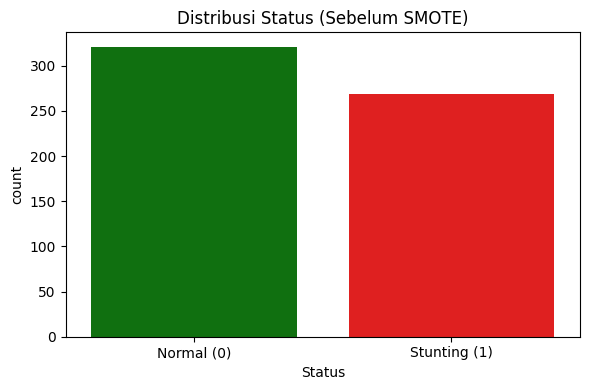

In [103]:
print("Distribusi Kelas Setelah Injeksi:")
print(df_fitur["Status"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_fitur, x="Status", hue="Status", palette={0: "green", 1: "red"}, legend=False)
plt.title("Distribusi Status (Sebelum SMOTE)")
plt.xticks(ticks=[0,1], labels=["Normal (0)", "Stunting (1)"])
plt.tight_layout()
plt.show()


### 6. Penyeimbangan Data dengan SMOTE

In [104]:
X = df_fitur.drop(columns=['Status'])
y = df_fitur['Status']

print("Distribusi kelas SEBELUM SMOTE:")
print(y.value_counts())

# Inisialisasi SMOTE (Hanya akan menyamakan jumlah minoritas ke mayoritas)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Gabungkan hasil ke DataFrame final
df_final = pd.concat([X_resampled, y_resampled], axis=1)

# Acak urutan agar Normal dan Stunting bercampur
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi kelas SESUDAH SMOTE:")
print(df_final['Status'].value_counts())
print(f"\nTotal Data Latih Siap Pakai: {len(df_final)} baris")


Distribusi kelas SEBELUM SMOTE:
Status
0    321
1    269
Name: count, dtype: int64

Distribusi kelas SESUDAH SMOTE:
Status
0    321
1    321
Name: count, dtype: int64

Total Data Latih Siap Pakai: 642 baris


### Visualisasi Hasil SMOTE (EDA)

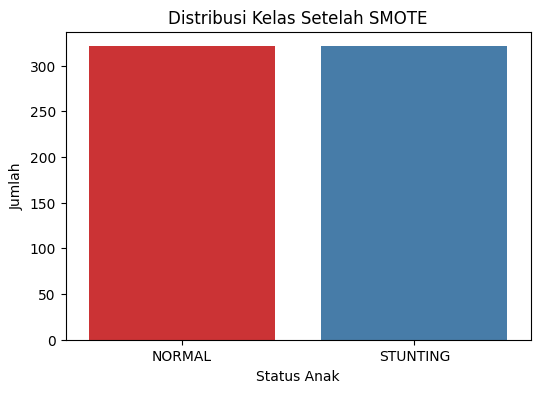

Total data sekarang: 642 baris


In [105]:
plt.figure(figsize=(6, 4))
# Mengubah y_resampled menjadi DataFrame sementara untuk visualisasi
df_resampled = pd.DataFrame({'Status': y_resampled})
df_resampled['Status_Label'] = df_resampled['Status'].map({0: 'NORMAL', 1: 'STUNTING'})

sns.countplot(data=df_resampled, x='Status_Label', palette='Set1')
plt.title('Distribusi Kelas Setelah SMOTE')
plt.xlabel('Status Anak')
plt.ylabel('Jumlah')
plt.show()

print(f"Total data sekarang: {len(X_resampled)} baris")


### 7. Simpan Dataset

In [106]:
# Simpan ke folder processed
df_final.to_csv('../data/processed/dataset_final_training.csv', index=False)
print("Data training SMOTE berhasil disimpan ke 'data/processed/dataset_final_training.csv'")
df_final.head()


Data training SMOTE berhasil disimpan ke 'data/processed/dataset_final_training.csv'


,Umur (Bulan),Jenis Kelamin,BB_Awal,TB_Awal,BB_Akhir,TB_Akhir,Lama_Pantau_Bulan,Kecepatan_Tumbuh_BB,Kecepatan_Tumbuh_TB,Rasio_BB_TB_Akhir,Z_Score_Akhir,Status
0,60,0,12.100000,101.000000,14.500000,101.000000,5,0.600000,0.000000,0.143563,-1.541041,0
1,20,1,10.900000,76.800000,11.400000,79.100000,3,0.270000,1.140000,0.144121,-1.493358,0
2,43,0,10.300000,79.900000,10.300000,80.700000,4,0.010000,0.270000,0.127633,-3.910182,1
3,53,1,15.715877,87.977784,15.931754,89.584123,6,0.043175,0.325871,0.177852,-3.622891,1
4,60,1,11.000000,93.000000,11.700000,95.500000,5,0.175000,0.625000,0.122512,-3.082630,1
